# Load packages

Read in all necessary packages:

In [11]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc
import numpy as np
import decoupler as dc


In [2]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [3]:
import decoupler as dc

In [4]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

## load adata file and define groups for differential expression

In [5]:
adata = sc.read_h5ad('../../../tchic_local/fig6_build/legacy/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

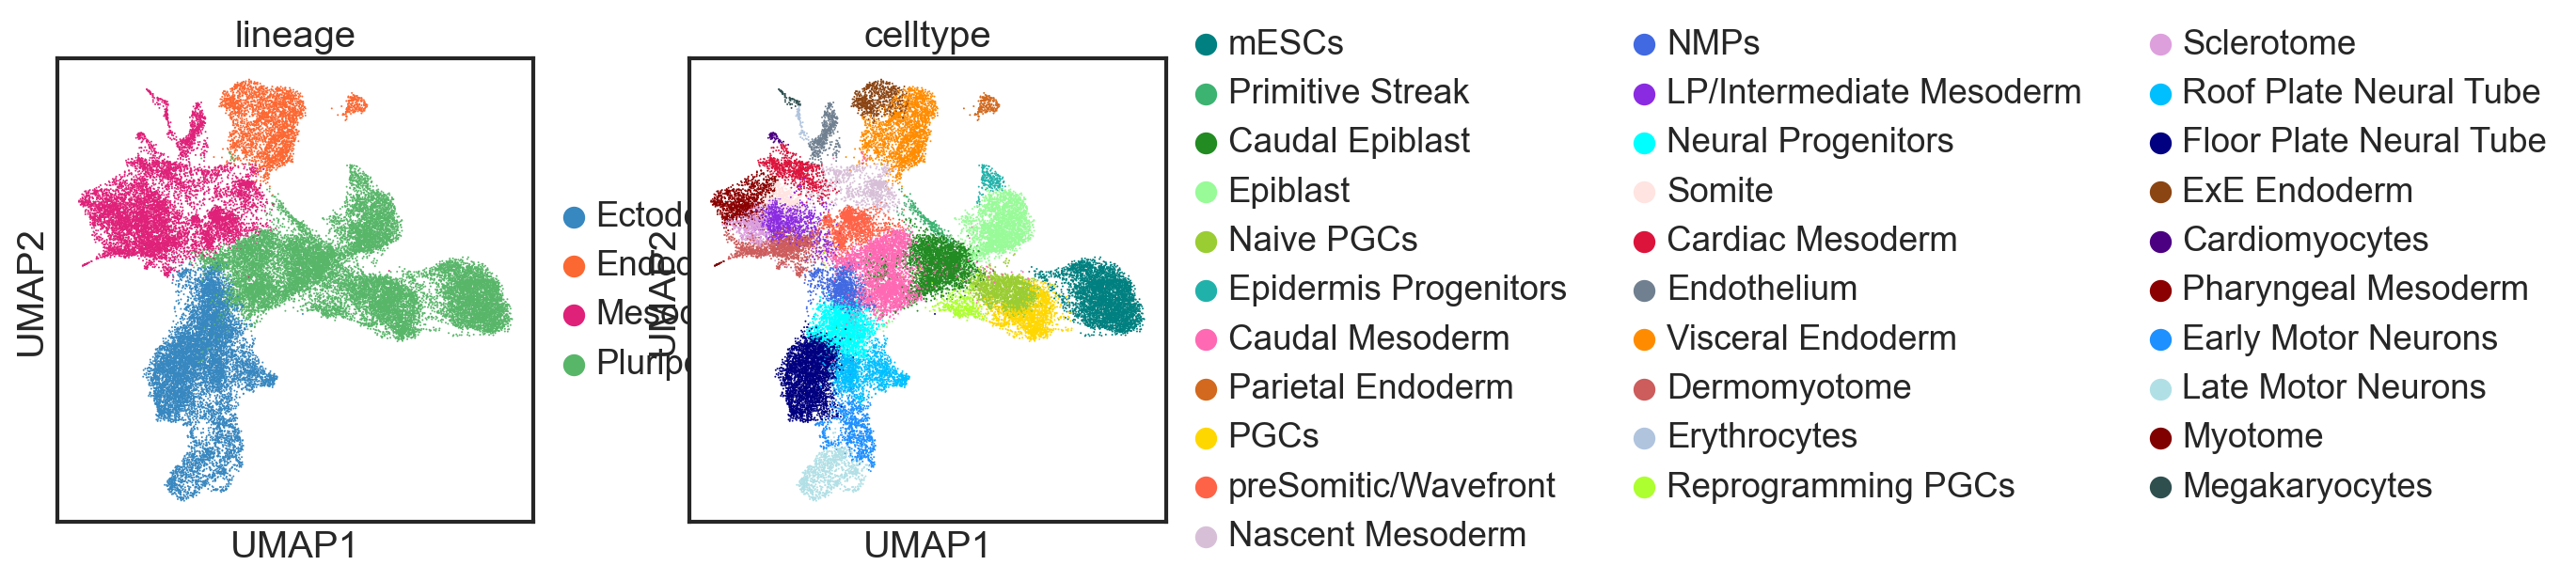

In [6]:
sc.pl.umap(adata, color = ['lineage', 'celltype'])

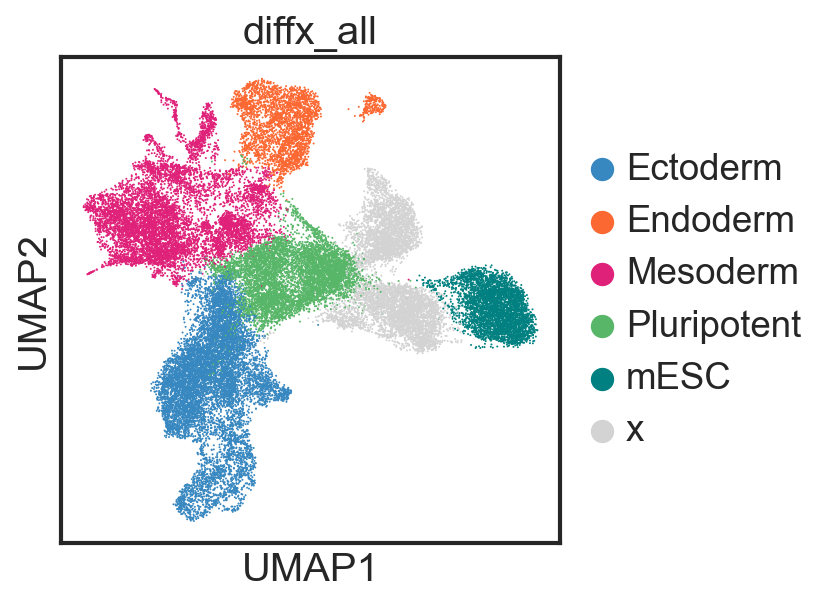

In [7]:
dict_ct = {'Mesoderm':'Mesoderm',
 'Ectoderm':'Ectoderm',
 'Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent'}

adata.obs['diffx_all'] = (
    adata.obs["lineage"]
    .map(lambda x: dict_ct.get(x, x))
    .astype("category")
)

adata.obs['diffx_all'] = adata.obs['diffx_all'].astype(str)
adata.obs.loc[list(adata[adata.obs['celltype'] == 'mESCs'].obs.index), 'diffx_all'] = 'mESC'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'PGCs'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epidermis Progenitors'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epiblast'].obs.index), 'diffx_all'] = 'x'

cols = ['#3787c0', '#fc6832','#df2179', '#58b669','teal','lightgrey']
sc.pl.umap(adata, color = 'diffx_all', palette = cols )

## all comparisons

In [8]:
dict_ct = {'Mesoderm':'x','Ectoderm':'x','Endoderm':'x',
           'Pluripotent':'Pluripotent','x':'x','mESC':'mESC'}
adata.obs['diffx_ESC_p'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))


dict_ct = {'Mesoderm':'diff','Ectoderm':'diff','Endoderm':'diff',
           'Pluripotent':'Pluripotent','x':'x','mESC':'x'}
adata.obs['diffx_p_diff'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))

dict_ct = {'Mesoderm':'Mesoderm','Ectoderm':'Ectoderm','Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent','x':'x','mESC':'x'}
adata.obs['diffx_diff_p'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))

adata.uns['diffx_ESC_p_colors'] = ['#58b669','teal','lightgrey']
adata.uns['diffx_p_diff_colors'] = ['#58b669','#df2179','lightgrey']
adata.uns['diffx_diff_p_colors'] = ['#3787c0', '#fc6832','#df2179', '#58b669','lightgrey']

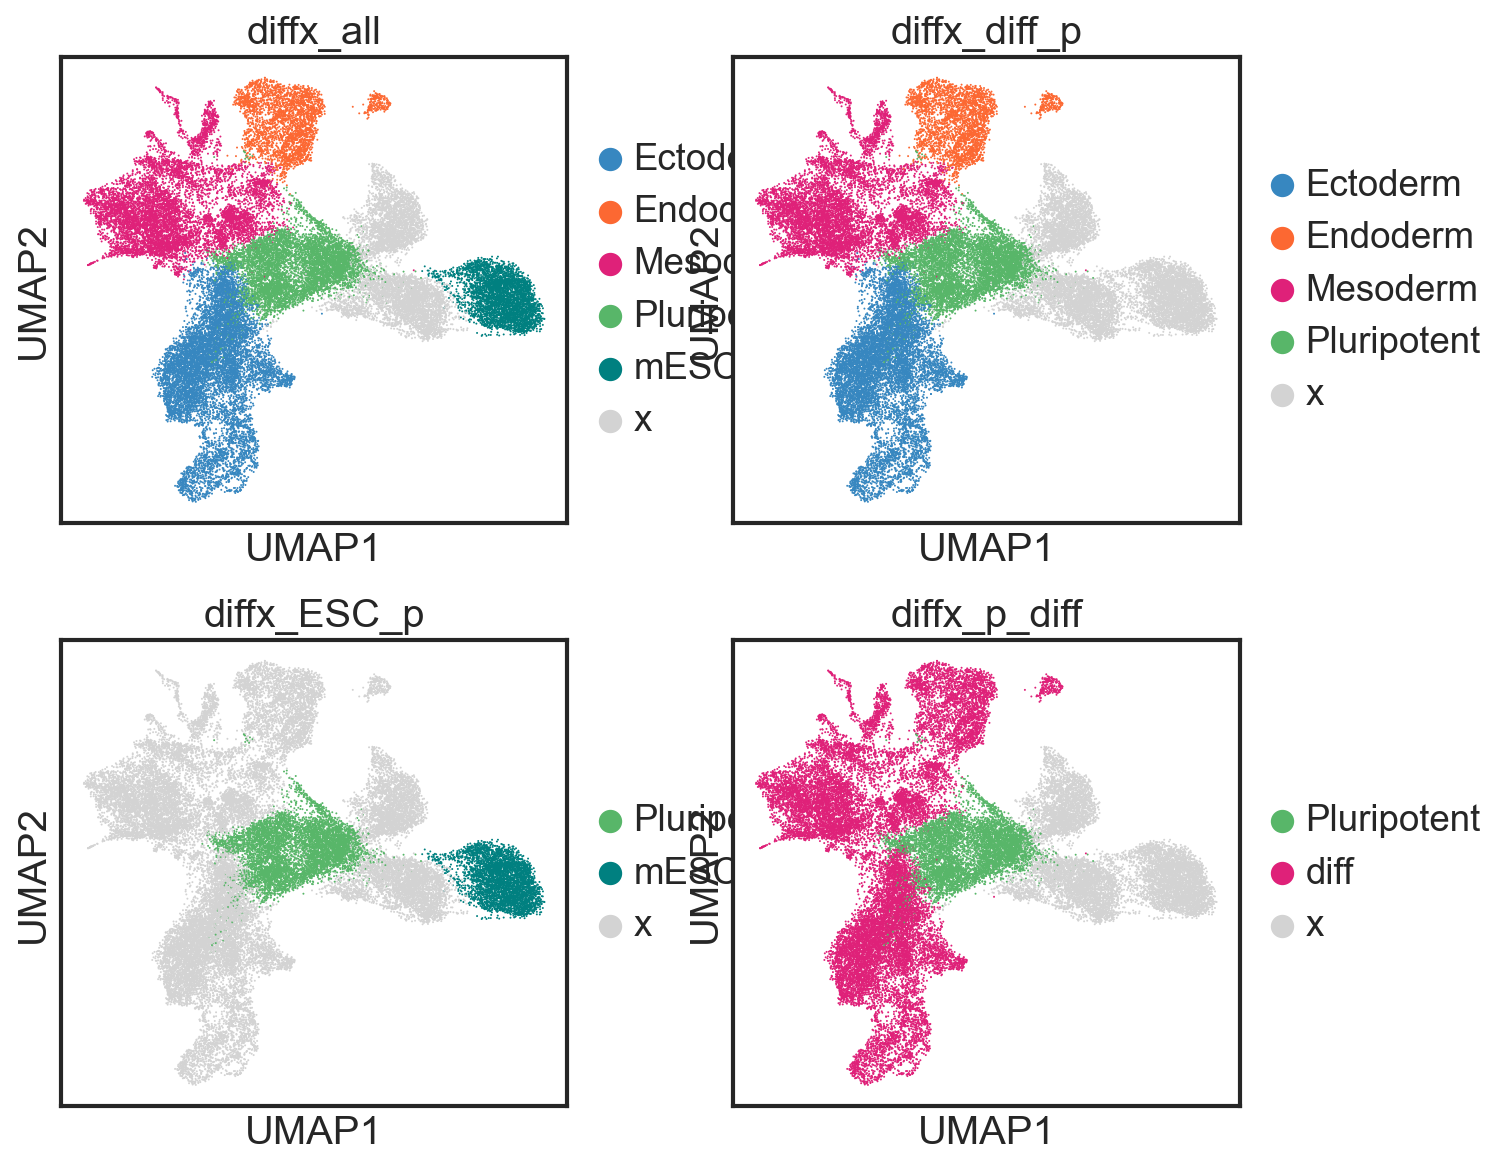

In [9]:
sc.pl.umap(adata, color = ['diffx_all','diffx_diff_p','diffx_ESC_p','diffx_p_diff'], ncols = 2)

In [10]:
sc.settings.verbosity = 2

## load the tables with differentially expressed genes

In [12]:
PvsDIFF = pd.read_csv('dfs/20250310_diff_genes_PvsDIFF.csv')
ESCvsP = pd.read_csv('dfs/20250310_diff_genes_ESCvsP.csv')
PvsECT = pd.read_csv('dfs/20250310_diff_genes_PvsECT.csv')
PvsEND = pd.read_csv('dfs/20250310_diff_genes_PvsEND.csv')
PvsMES = pd.read_csv('dfs/20250310_diff_genes_PvsMES.csv')

In [13]:
def up_down_genes(results_df):
    up = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 2)].sort_values(by = 'log2FoldChange',ascending=True)
    down = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] < -2)].sort_values(by = 'log2FoldChange',ascending=True)
    return up,down


In [14]:
PvsDIFF_up, PvsDIFF_down = up_down_genes(PvsDIFF)
ESCvsP_up, ESCvsP_down = up_down_genes(ESCvsP)
PvsECT_up, PvsECT_down = up_down_genes(PvsECT)
PvsEND_up, PvsEND_down = up_down_genes(PvsEND)
PvsMES_up, PvsMES_down = up_down_genes(PvsMES)

In [15]:
print('up, \t \t \t down')
print( PvsDIFF_up.shape[0]/PvsDIFF.shape[0]*100,
      PvsDIFF_down.shape[0]/PvsDIFF.shape[0]*100)

print( ESCvsP_up.shape[0]/ESCvsP.shape[0]*100,
      ESCvsP_down.shape[0]/ESCvsP.shape[0]*100)

print( PvsECT_up.shape[0]/PvsECT.shape[0]*100,
      PvsECT_down.shape[0]/PvsECT.shape[0]*100)

print( PvsEND_up.shape[0]/PvsEND.shape[0]*100,
      PvsEND_down.shape[0]/PvsEND.shape[0]*100)

print( PvsMES_up.shape[0]/PvsMES.shape[0]*100,
      PvsMES_down.shape[0]/PvsMES.shape[0]*100)

up, 	 	 	 down
4.225513836261339 1.2630612010563786
5.600382932166302 5.648249452954048
3.6784126779617345 2.6541261354119694
5.713497101849296 2.773944245100745
4.539845424433331 2.2212119244008575


# Take only unique differentially expressed genes

For the lineages, we take the "up" fraction - these are upregulated in lin vs pluripotent. \
For pluripotency, we take the "down" fraction in p vs diff - these are downregulated in the lineages compared to pluripotency, i.e. they are up in pluripotency. \
For ESCs, we take the "down" fraction in ESC vs p - these are donwregulated in ESCs compared to P. The "up" fraction is differentially expresssed in pluripotent compared to ESCs.

In [21]:
ecto = PvsECT_up[~PvsECT_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsMES_up['Gene']))]
meso = PvsMES_up[~PvsMES_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsECT_up['Gene']))]
endo = PvsEND_up[~PvsEND_up['Gene'].isin(list(PvsECT_up['Gene']) + list(PvsMES_up['Gene']))]
pluri = PvsDIFF_down

In [34]:
metadata = pd.read_csv('../../../tchic_local/fig6_build/dfs/20250215_metadata.tsv', index_col = 0, header = 0, low_memory= False, sep = '\t')

In [35]:
metadata.head(2)

,step,PT,UMAP1,UMAP2,lin,RT,lin2,RT_m,step_id
1,1,0.372537,11.126464,4.599585,ect1,mESCs,Pluripotent mESCs,0.0,1:ect1
2,2,0.463342,11.385221,4.509028,ect1,mESCs,Pluripotent mESCs,0.0,2:ect1


In [37]:
count_table = pd.read_csv('../../../tchic_local/fig6_build/dfs/20250304_count_data_all_thresh_min.tsv', sep = '\t', index_col = 0)

In [38]:
count_table.index = count_table['gene']
count_table.head(2)

,gene,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn
gene,,,,,,,,,,
Xkr4,Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0
Rp1,Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0


In [39]:
d_rna = {}
d_k4 = {}
d_k27 = {}
df_rna = count_table[count_table['layer'] == 'RNA']
df_k4 = count_table[count_table['layer'] == 'K4']
df_k27 = count_table[count_table['layer'] == 'K27']

df_rna = df_rna.drop('gene',axis=1)
df_k4 = df_k4.drop('gene',axis=1)
df_k27 = df_k27.drop('gene',axis=1)

In [40]:
df_rna['p_99'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],99)
df_k4['p_99'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],99)
df_k27['p_99'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],99)

df_rna['p_98'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],98)
df_k4['p_98'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],98)
df_k27['p_98'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],98)

df_rna['p_95'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],95)
df_k4['p_95'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],95)
df_k27['p_95'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],95)

In [41]:
ct_normalised = pd.concat([df_rna,df_k4,df_k27])

In [42]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95
gene,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,0.047819,0.069934,0.125110
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0,0.046809,0.068456,0.122467


In [43]:
ct_normalised['p98_log2'] = np.log2(ct_normalised['p_98']+1)
ct_normalised['p98_log10'] = np.log10(ct_normalised['p_98']+1)

ct_normalised['step_id'] = ct_normalised['step'].astype(str) + str(':') + ct_normalised['lin']
metadata['step_id'] = metadata['step'].astype(str) + str(':') + metadata['lin']
steps_to_RT = metadata[['step_id','RT']].set_index('step_id').to_dict()['RT']
ct_normalised['RT'] = ct_normalised['step_id'].map(steps_to_RT)
ct_normalised['RT'] = ct_normalised['RT'].astype('category')
ct_normalised['RT'] = ct_normalised['RT'].cat.reorder_categories(['mESCs','Gastd3', 'Gastd4', 'Gastd5', 'Gastd6', 'Gastd7'])
ct_normalised['lin_layer'] = ct_normalised['lin'].astype(str) + str('_') + ct_normalised['layer'].astype(str)


In [44]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95,p98_log2,p98_log10,step_id,RT,lin_layer
gene,,,,,,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,0.047819,0.069934,0.125110,0.097521,0.029357,1:ect1,mESCs,ect1_RNA
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0,0.046809,0.068456,0.122467,0.095528,0.028757,1:ect1,mESCs,ect1_RNA


In [45]:
to_plot1 = ct_normalised.loc[list(set(endo['Gene']) & set(ct_normalised.index))]
to_plot2 = ct_normalised.loc[list(set(meso['Gene']) & set(ct_normalised.index))]
to_plot3 = ct_normalised.loc[list(set(ecto['Gene']) & set(ct_normalised.index))]
to_plot4 = ct_normalised.loc[list(set(pluri['Gene']) & set(ct_normalised.index))]

In [46]:
lin_colors = {'Ectoderm':'#3787C0', 'Endoderm':'#FC6832', 'Mesoderm':'#DF2179'}
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'

lightOrange = '#f59c71'
lightGreen = '#90f5b1'
lightPurple = '#b698fa'

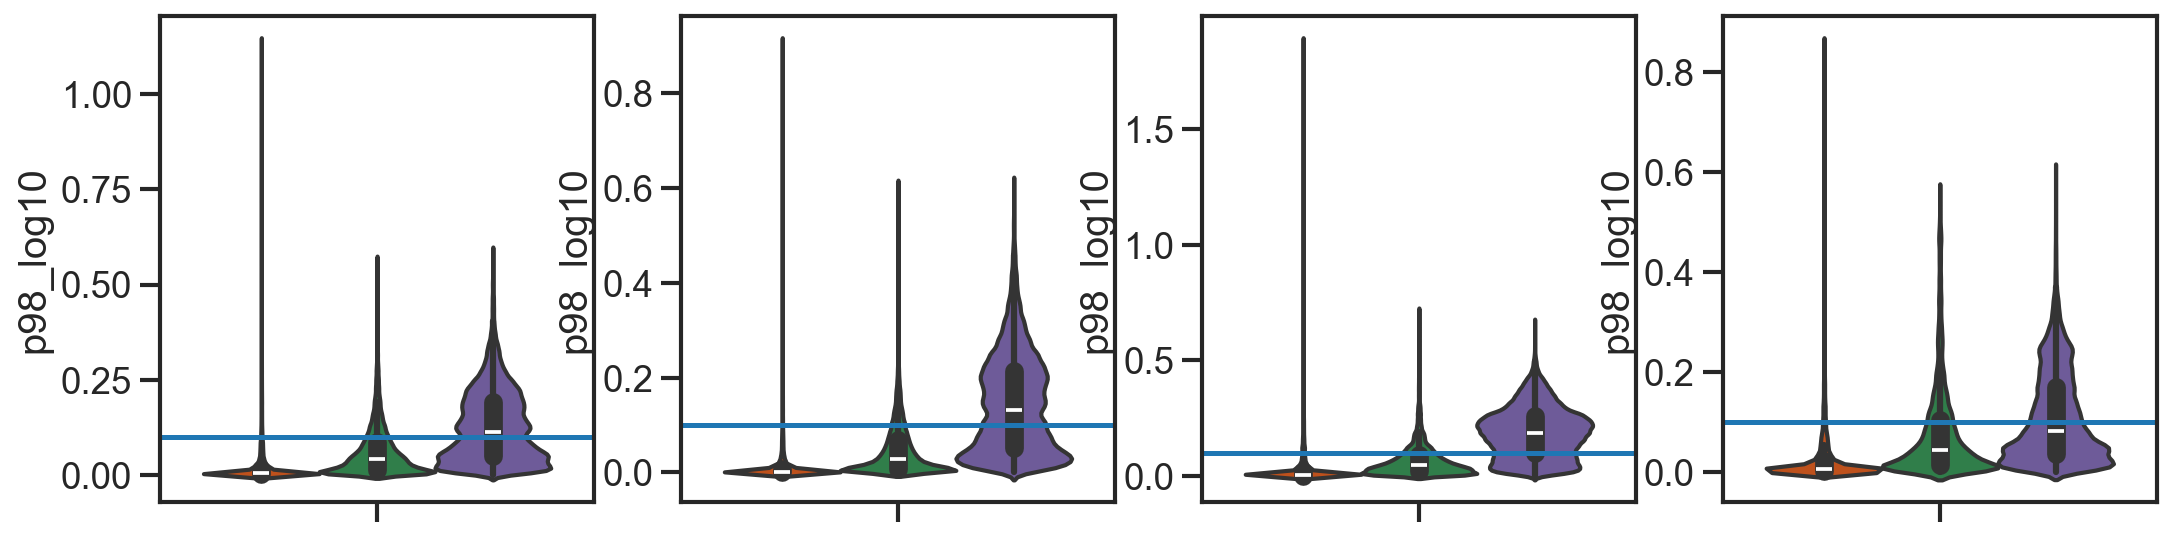

In [47]:
fig,ax=plt.subplots(1,4,figsize = (16,4))
plotting = [to_plot1,to_plot2,to_plot3,to_plot4]
for num,p in enumerate(plotting):
    sns.violinplot(data = p[['layer','p98_log10']],
                hue = 'layer',ax=ax[num],
                y = 'p98_log10',
                   legend=False,
                  palette = [Orange,Green,Purple])
    ax[num].axhline(0.1)

plt.show()

In [49]:
def linePlotPerTrajectory(df,lin, genelist, hue = 'layer', xval = 'step', yval='p_99',save = None):
    #to_plot = df.loc[genelist]
    fig,ax = plt.subplots(figsize = (12,4))
  #  sns.lineplot(data = df[df['lin'] != lin], linewidth = 2,
  #               ax=ax,
  #                  x = xval,
  #                  y = yval,
  #                  hue = hue,alpha=0.5,
  #                  palette = [lightOrange,lightOrange,lightOrange,lightOrange,lightOrange,lightOrange,
  #                             lightGreen,lightGreen,lightGreen,lightGreen,lightGreen,lightGreen,
  #                             lightPurple,lightPurple,lightPurple,lightPurple,lightPurple,lightPurple],errorbar = None,)
                  # hue_order = ['RNA','K4','K27'])
    
    sns.lineplot(data = df[df['lin'] == lin], linewidth = 4,
                 ax=ax,
                    x = xval,
                    y = yval,
                    hue = 'layer',
                    palette = [Orange,Green, Purple],errorbar = None,
                   hue_order = ['RNA','K4','K27'])
    
    plt.legend([],frameon = False)
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()

In [50]:
gene = ['Sox17']
df_to_plot = ct_normalised.loc[gene]

In [52]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

import scipy 

def plotheatmap(count_table, lineage = 'ect1',genelist = ['Onecut2'], val = 'sm',xval = 'step', save = None,aspect_ratio = 0.01):

    #f = count_table[(count_table['lin'] == lineage)].loc[genelist][[val, 'modality','step']]
    df = pd.pivot_table(count_table[count_table['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
    df = df[genelist]
    order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(df.T.fillna(0)))
    df = df.iloc[:,order]

    fig,ax=plt.subplots(4, 1, figsize=(12,len(genelist)*aspect_ratio), height_ratios = [0.4,0.2,0.2,0.2], 
                        gridspec_kw = {'wspace':0, 'hspace':0.05})
    

    df_rna = df.loc['RNA']
    df_k4 = df.loc['K4']
    df_k27 = df.loc['K27']
    
    df_k271 = pd.DataFrame(df_k27.unstack()).rename(columns={0:'vals'})
    df_k271['mod'] = 'k27'
    df_k41 = pd.DataFrame(df_k4.unstack()).rename(columns={0:'vals'})
    df_k41['mod'] = 'k4'
    df_rna1 = pd.DataFrame(df_rna.unstack()).rename(columns={0:'vals'})
    df_rna1['mod'] = 'rna'
        
    sns.lineplot(data = pd.concat([df_k271, df_k41, df_rna1]), ax=ax[0],
                    x = xval,
                    y = 'vals',
                    hue = 'mod',
                     hue_order = ['rna','k4','k27'],
                    palette = [Orange, Green, Purple])
    
    sns.heatmap(data = df_rna.T,#.iloc[order],
                cbar = False,vmax=0.2,
                ax=ax[1],
               cmap = oranges_r)
    sns.heatmap(data = df_k4.T,#.iloc[order],
                cbar = False,vmax = 0.4,
                ax=ax[2],
               cmap = greens_r)
    sns.heatmap(data = df_k27.T,#.iloc[order],
                cbar = False,vmax = 0.9,
                ax=ax[3],
               cmap = purples_r)
    for x in range(4):
        ax[x].legend([],frameon=False)
        ax[x].set_xticks([])
        ax[x].set_xlabel('')
        ax[x].set_yticks([])
        ax[x].set_ylabel('')   
    
    #ax[0].set_xlim(df_k271.index.get_level_values(xval).unique()[[0,-1]])
    ax[0].set_ylim([0,0.81])
    ax[0].set_yticks([0,0.2,0.4,0.6,0.8])
    ax[3].set_xlabel('pseudotime')
    ax[2].set_ylabel('genes')

    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()
    plt.close()


def plotheatmap_only(count_table, lineage = 'ect1',genelist = ['Onecut2'], val = 'sm', vmax_rna = 0.6, vmax_k4 = 0.5, vmax_k27 = 0.8,
                     xval = 'step', save = None,aspect_ratio = 0.01):

    #f = count_table[(count_table['lin'] == lineage)].loc[genelist][[val, 'modality','step']]
    df = pd.pivot_table(count_table[count_table['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
    df = df[genelist]
    order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(df.T.fillna(0)))
    df = df.iloc[:,order]

    fig,ax=plt.subplots(3, 1, figsize=(12,len(genelist)*aspect_ratio), height_ratios = [0.2,0.2,0.2], 
                        gridspec_kw = {'wspace':0, 'hspace':0.05})
    
    df_rna = df.loc['RNA']
    df_k4 = df.loc['K4']
    df_k27 = df.loc['K27']
    
    sns.heatmap(data = df_rna.T,#.iloc[order],
                cbar = False,vmax=vmax_rna,
                ax=ax[0],
               cmap = oranges_r)
    sns.heatmap(data = df_k4.T,#.iloc[order],
                cbar = False,vmax = vmax_k4,
                ax=ax[1],
               cmap = greens_r)
    sns.heatmap(data = df_k27.T,#.iloc[order],
                cbar = False,vmax = vmax_k27,
                ax=ax[2],
               cmap = purples_r)
    for x in range(3):
        ax[x].legend([],frameon=False)
        ax[x].set_xticks([])
        ax[x].set_xlabel('')
        ax[x].set_yticks([])
        ax[x].set_ylabel('')   
    
    ax[2].set_xlabel('pseudotime')
    ax[1].set_ylabel('genes')

    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()
    plt.close()


def plotline(count_table, lineage = 'ect1',genelist = ['Onecut2'], val = 'sm',xval = 'step', save = None,figsize = (4,4)):

    df = pd.pivot_table(count_table[count_table['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
    fig,ax=plt.subplots(figsize=(figsize))
    

    df_rna = df.loc['RNA']
    df_k4 = df.loc['K4']
    df_k27 = df.loc['K27']

    df_rna = df_rna[genelist]
    df_k4 = df_k4[genelist]
    df_k27 = df_k27[genelist]
    
    # order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(df.T.fillna(0)))
    df_k271 = pd.DataFrame(df_k27.unstack()).rename(columns={0:'vals'})
    df_k271['mod'] = 'k27'
    df_k41 = pd.DataFrame(df_k4.unstack()).rename(columns={0:'vals'})
    df_k41['mod'] = 'k4'
    df_rna1 = pd.DataFrame(df_rna.unstack()).rename(columns={0:'vals'})
    df_rna1['mod'] = 'rna'
        
    sns.lineplot(data = pd.concat([df_k271, df_k41, df_rna1]), ax=ax,
                    x = xval,
                    y = 'vals',
                    hue = 'mod',
                     hue_order = ['rna','k4','k27'],
                    palette = [Orange, Green, Purple])
    

    ax.legend([],frameon=False)
    
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')   
    
    #ax[0].set_xlim(df_k271.index.get_level_values(xval).unique()[[0,-1]])
    ax.set_ylim([0,1])
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1.0])
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()
    plt.close()

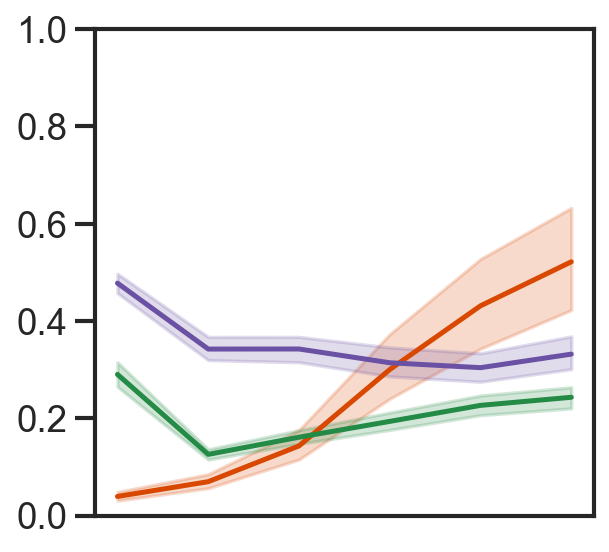

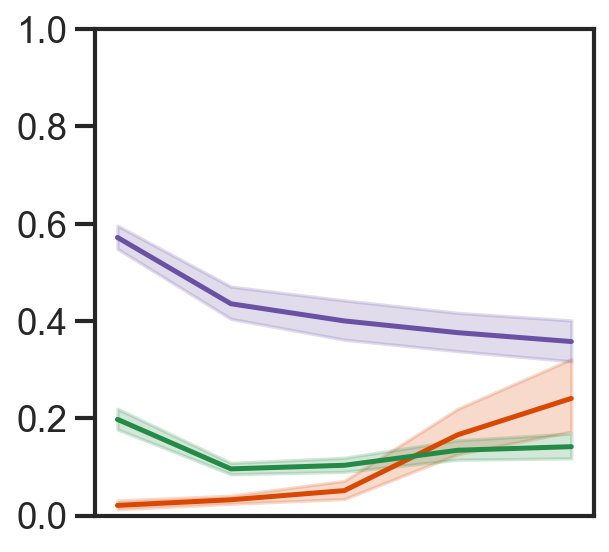

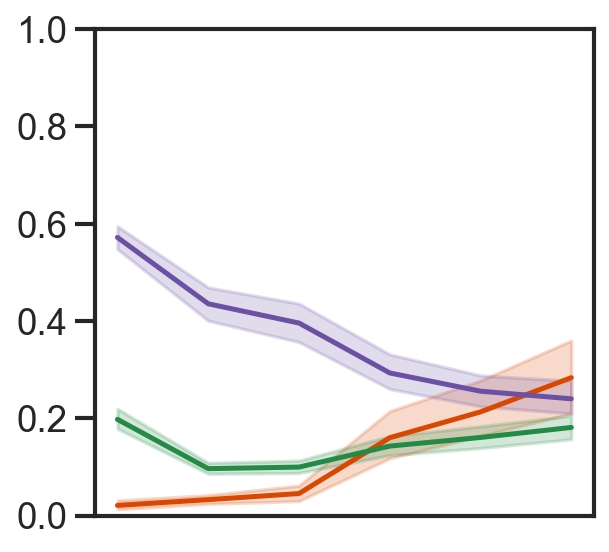

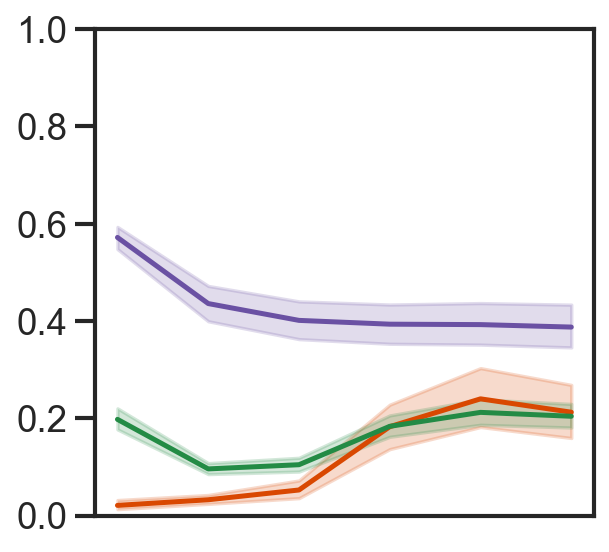

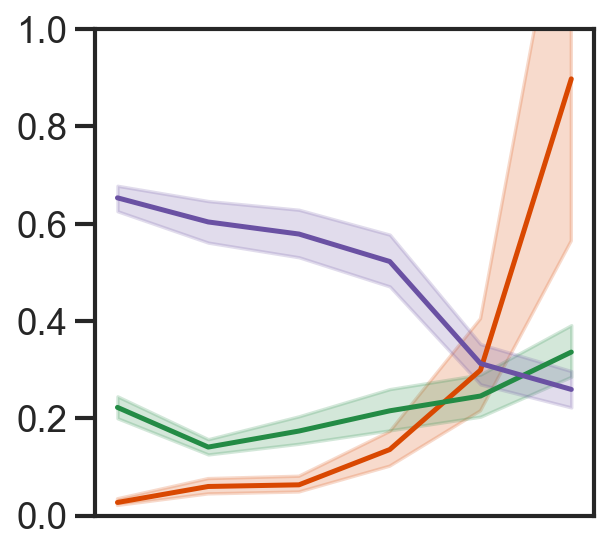

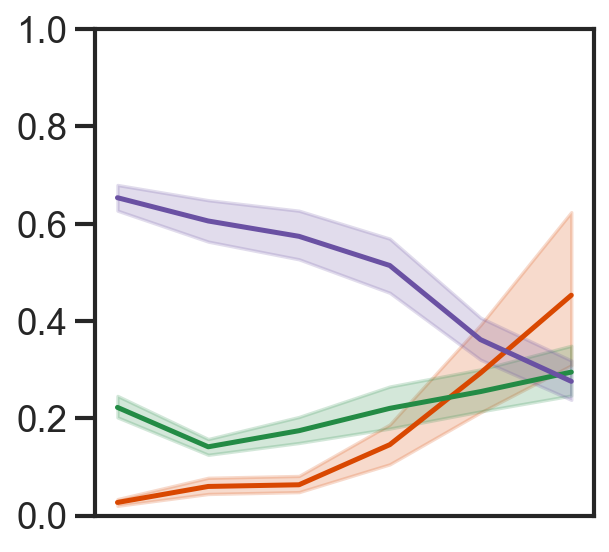

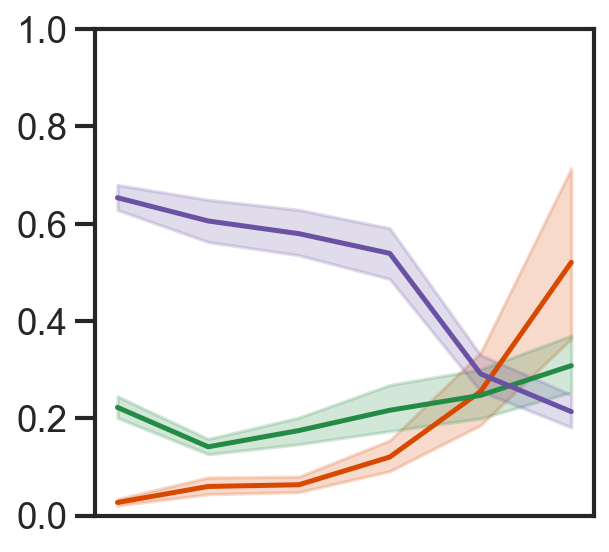

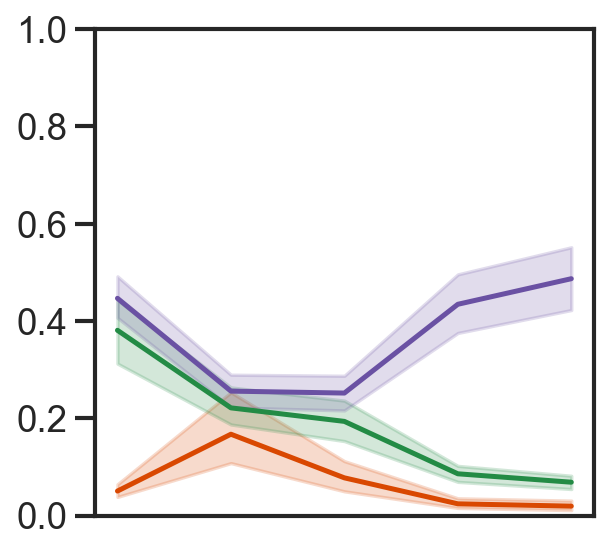

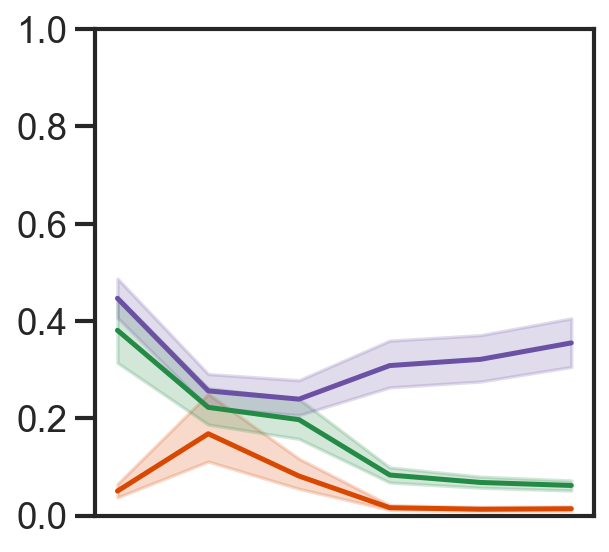

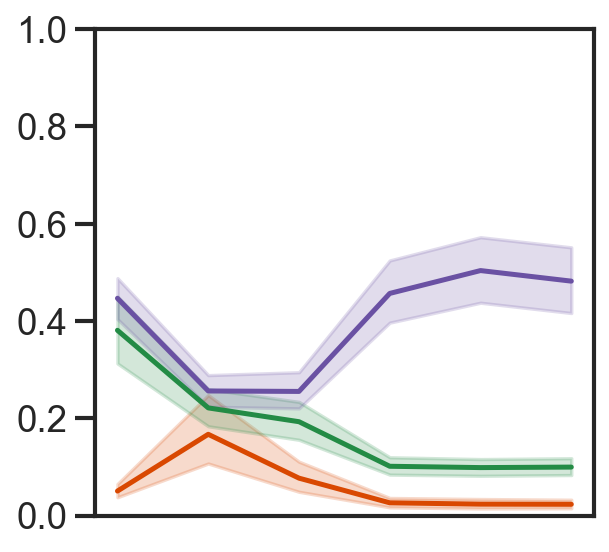

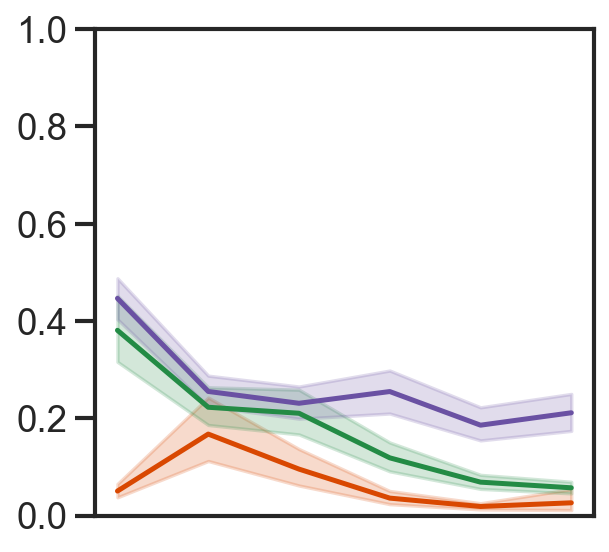

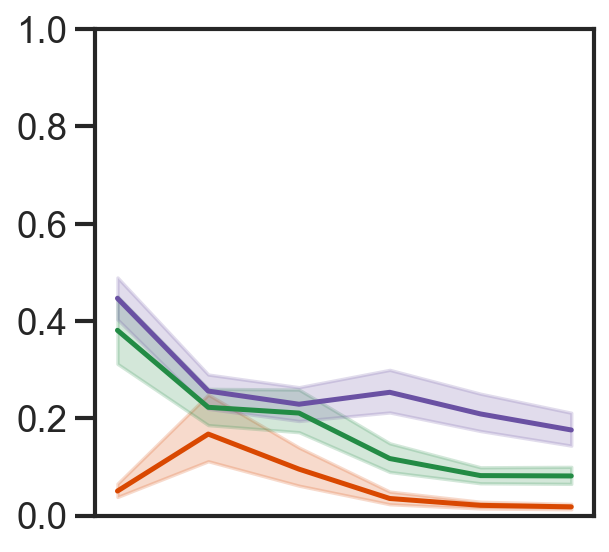

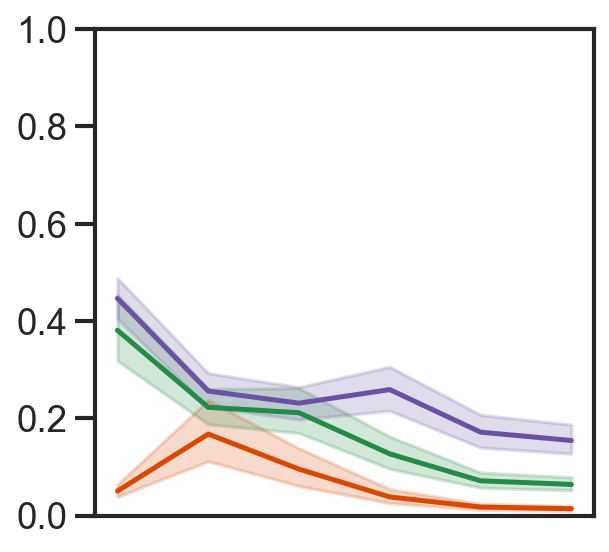

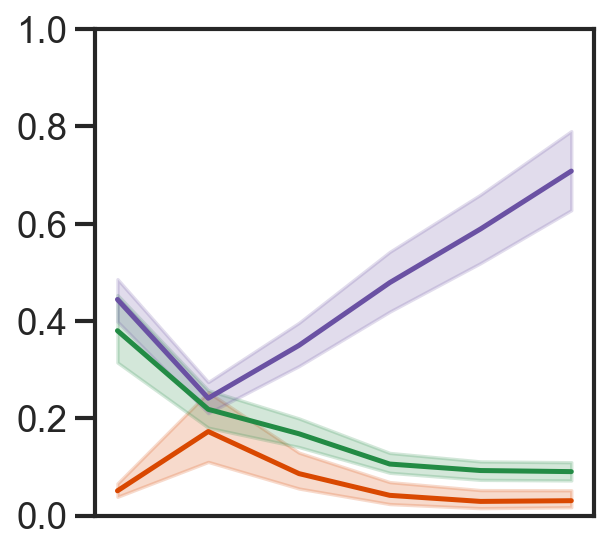

In [53]:
plotline(to_plot1, lineage = 'endo1', genelist = to_plot1.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_endogenes_endo1_RT.png')
plotline(to_plot2, lineage = 'mes1', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_mesogenes_mes1_RT.png')
plotline(to_plot2, lineage = 'mes2', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_mesogenes_mes2_RT.png')
plotline(to_plot2, lineage = 'mes3', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_mesogenes_mes3_RT.png')
plotline(to_plot3, lineage = 'ect1', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_ectogenes_ect1_RT.png')
plotline(to_plot3, lineage = 'ect2', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_ectogenes_ect2_RT.png')
plotline(to_plot3, lineage = 'ect3', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_ectogenes_ect3_RT.png')

plotline(to_plot4, lineage = 'mes1', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_mes1_RT.png')
plotline(to_plot4, lineage = 'mes2', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_mes2_RT.png')
plotline(to_plot4, lineage = 'mes3', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_mes3_RT.png')
plotline(to_plot4, lineage = 'ect1', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_ect1_RT.png')
plotline(to_plot4, lineage = 'ect2', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_ect2_RT.png')
plotline(to_plot4, lineage = 'ect3', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_ect3_RT.png')
plotline(to_plot4, lineage = 'endo1', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_endo1_RT.png')

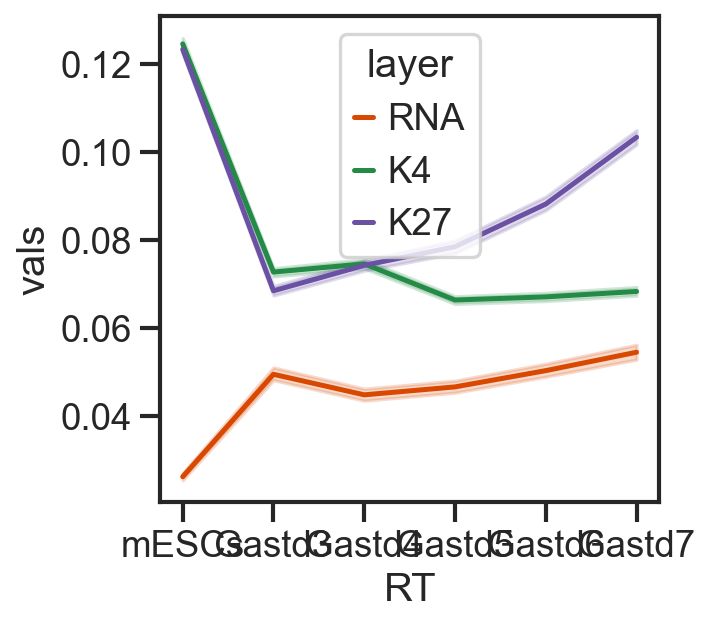

In [54]:
lineage = 'endo1'
val = 'p98_log10'
xval = 'RT'

df = pd.pivot_table(ct_normalised[ct_normalised['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
df_to_plot = pd.DataFrame(df.unstack().unstack()).rename(columns={0:'vals'})

sns.lineplot(data = df_to_plot,
                x = xval,
                y = 'vals',
                hue = 'layer',
                 hue_order = ['RNA','K4','K27'],
                palette = [Orange, Green, Purple])

plt.show()

In [104]:
all_source_target_genes = np.load('../dfs/source_target_genes.npy',allow_pickle='TRUE').item()

In [72]:
ect_target = list(set(to_plot3.index) & set(ect_target))

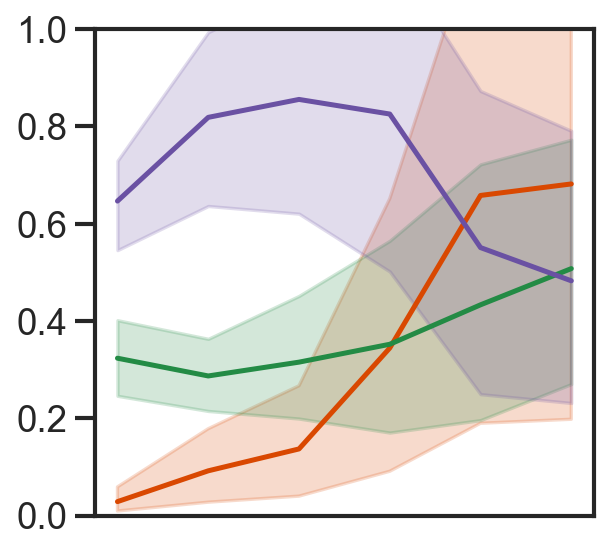

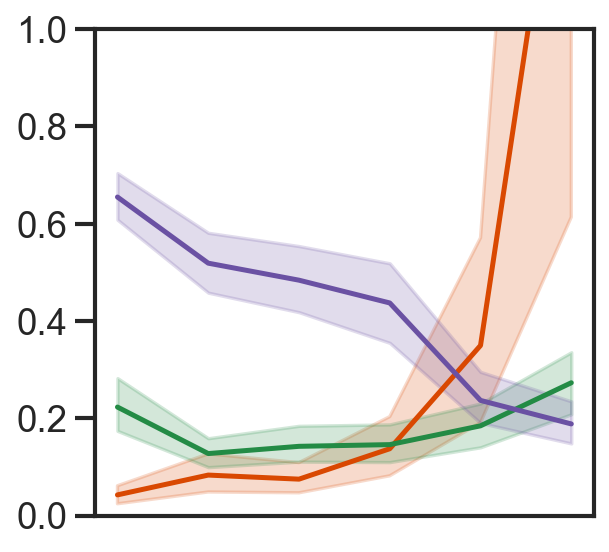

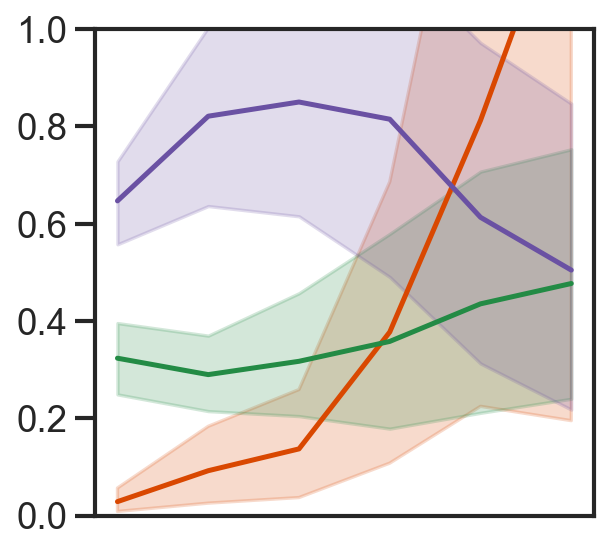

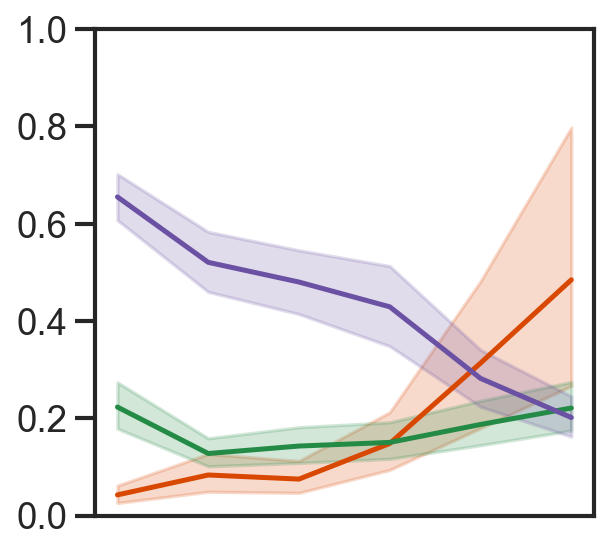

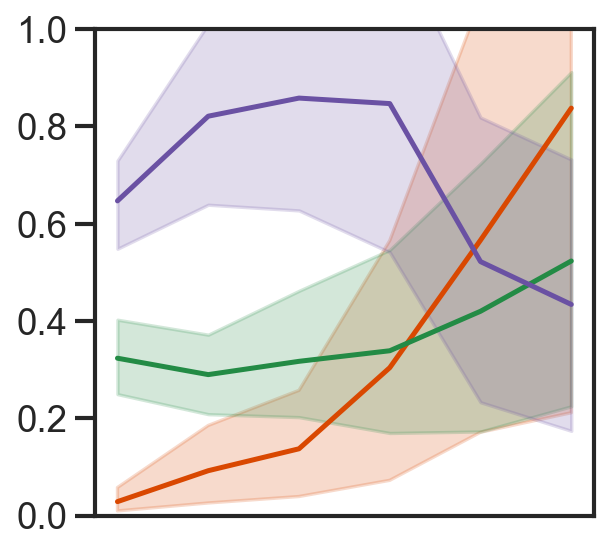

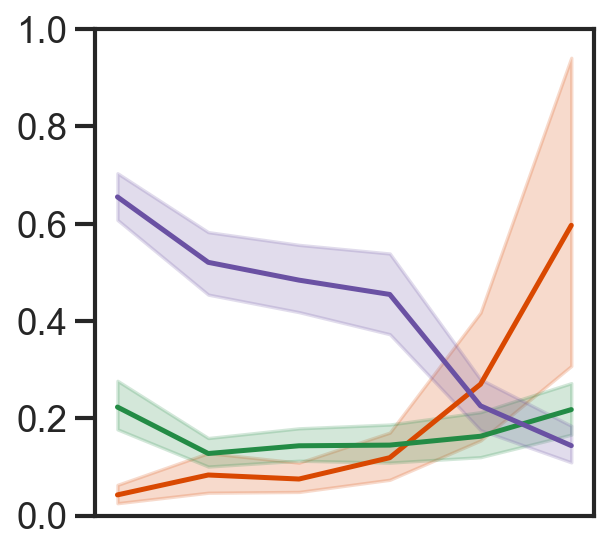

In [74]:
plotline(to_plot3, lineage = 'ect1', genelist = ect_source, val = 'p_98', xval = 'RT')#, save = 'figs/20250305_ectogenes_ect1_RT.png')
plotline(to_plot3, lineage = 'ect1', genelist = ect_target, val = 'p_98', xval = 'RT')#, save = 'figs/20250305_ectogenes_ect2_RT.png')

plotline(to_plot3, lineage = 'ect2', genelist = ect_source, val = 'p_98', xval = 'RT')#, save = 'figs/20250305_ectogenes_ect3_RT.png')
plotline(to_plot3, lineage = 'ect2', genelist = ect_target, val = 'p_98', xval = 'RT')#, save = 'figs/20250305_ectogenes_ect1_RT.png')

plotline(to_plot3, lineage = 'ect3', genelist = ect_source, val = 'p_98', xval = 'RT')#, save = 'figs/20250305_ectogenes_ect2_RT.png')
plotline(to_plot3, lineage = 'ect3', genelist = ect_target, val = 'p_98', xval = 'RT')#, save = 'figs/20250305_ectogenes_ect3_RT.png')


In [117]:
for x in range(3):
    print(x)

0
1
2


In [121]:
all_source_target_genes['ect_source']

{'Casz1',
 'Glis3',
 'Gsx1',
 'Irx5',
 'Lhx5',
 'Otp',
 'Pou3f4',
 'Rfx4',
 'Rorb',
 'Tfap2b',
 'Tox2',
 'Tox3',
 'Tshz3'}

In [189]:
def plot_source_target(df, lin, sourcelist, targetlist, xval = 'step', yval = 'p_98', save = None):
    fig, ax = plt.subplots(3,1, figsize = (4,5))
    hues = ['RNA','K4','K27']
    palette = [Orange,Green,Purple]
    palette2 = [lightOrange,lightGreen,lightPurple]
    for x in range(3):     
        sns.lineplot(data = df[(df['lin'] == lin) & (df.index.isin(all_source_target_genes[sourcelist]))],ax=ax[x],
               x = xval, hue_order = [hues[x]], palette = [palette[x]], linewidth = 3,ci = None,
               y = yval,
               hue = 'layer')
        sns.lineplot(data = df[(df['lin'] == lin) & (df.index.isin(all_source_target_genes[targetlist]))],ax=ax[x],
                   x = xval, hue_order = [hues[x]], palette = [palette2[x]], ci = None, alpha = 0.7, linewidth = 3,
                   y = yval,
                   hue = 'layer')
        ax[x].set_xticks([])
        ax[x].set_xlabel('')
        ax[x].set_ylabel('') 
        ax[x].legend([],frameon=False)
        ax[x].set_ylim([-0.05,1.2])
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()


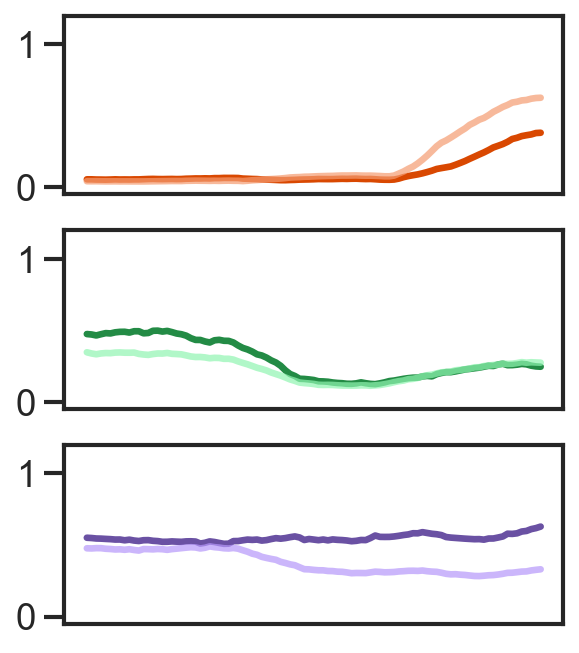

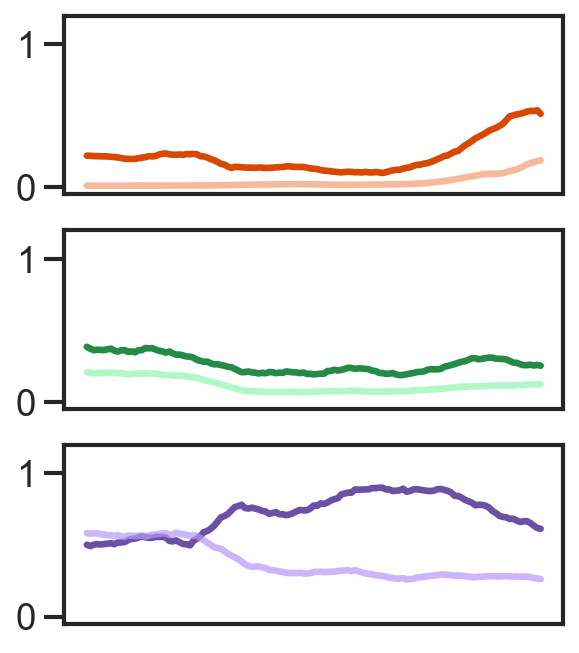

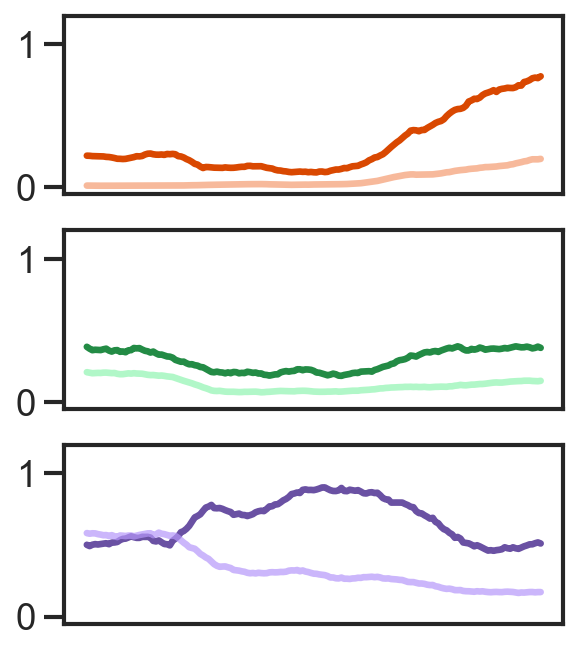

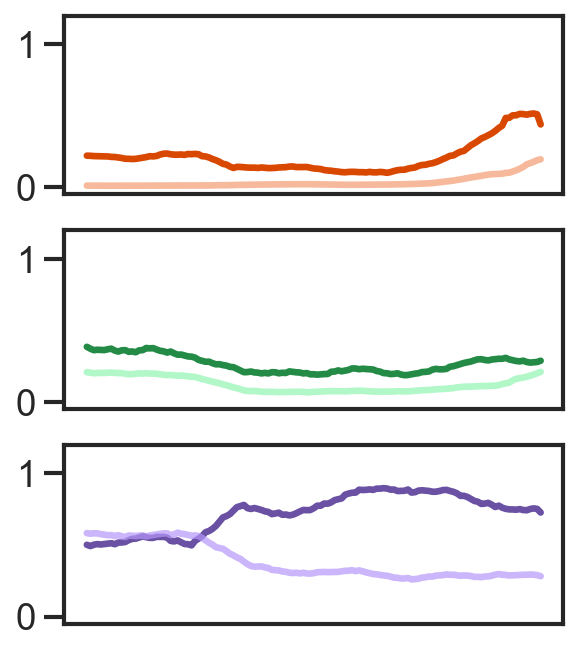

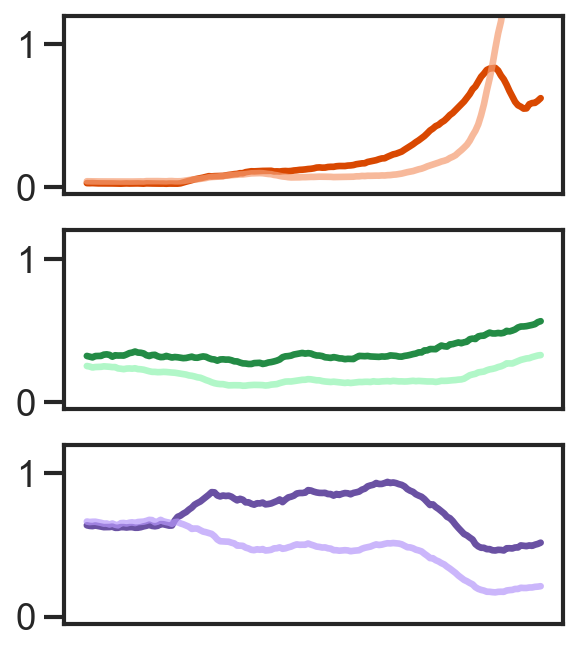

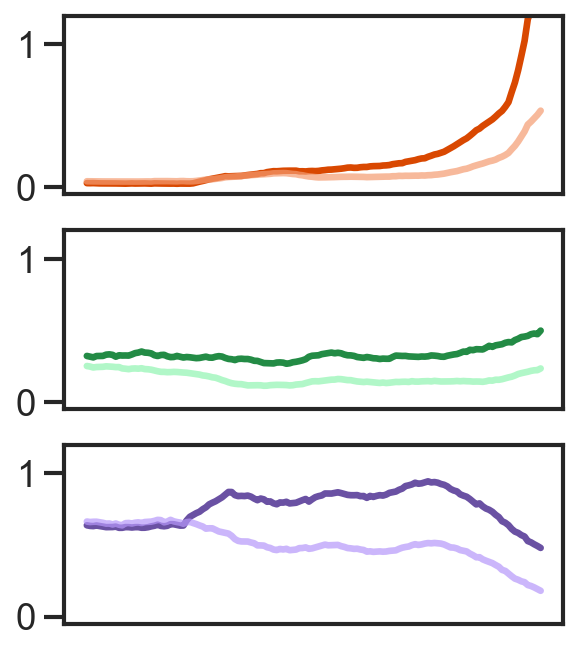

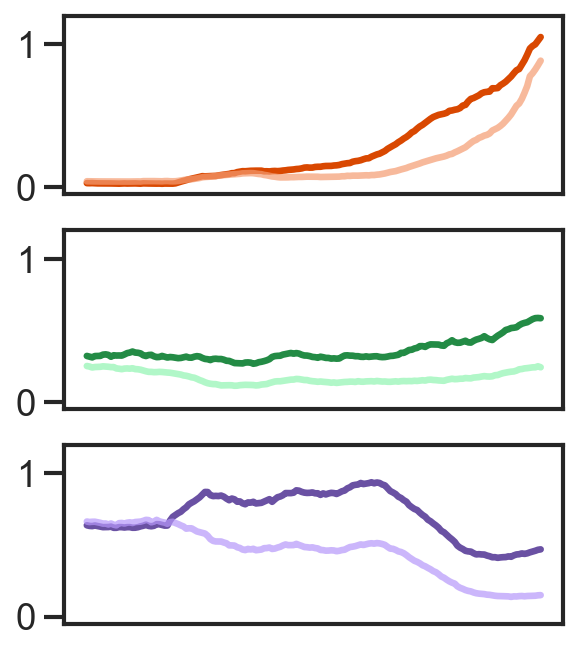

In [191]:
plot_source_target(to_plot1, 'endo1','end_source','end_target', save = 'figs/20250410_end1_source_target.png')

plot_source_target(to_plot2, 'mes1','mes_source','mes_target', save = 'figs/20250410_mes1_source_target.png')
plot_source_target(to_plot2, 'mes2','mes_source','mes_target', save = 'figs/20250410_mes2_source_target.png')
plot_source_target(to_plot2, 'mes3','mes_source','mes_target', save = 'figs/20250410_mes3_source_target.png')

plot_source_target(to_plot3, 'ect1','ect_source','ect_target', save = 'figs/20250410_ect1_source_target.png')
plot_source_target(to_plot3, 'ect2','ect_source','ect_target', save = 'figs/20250410_ect2_source_target.png')
plot_source_target(to_plot3, 'ect3','ect_source','ect_target', save = 'figs/20250410_ect3_source_target.png')

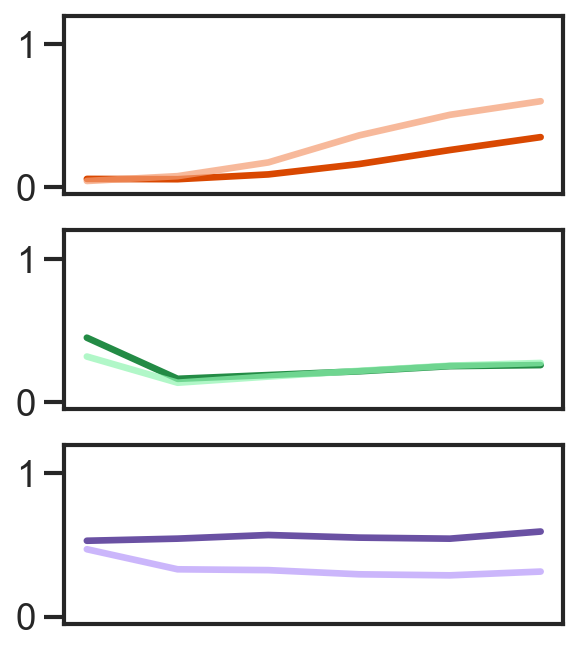

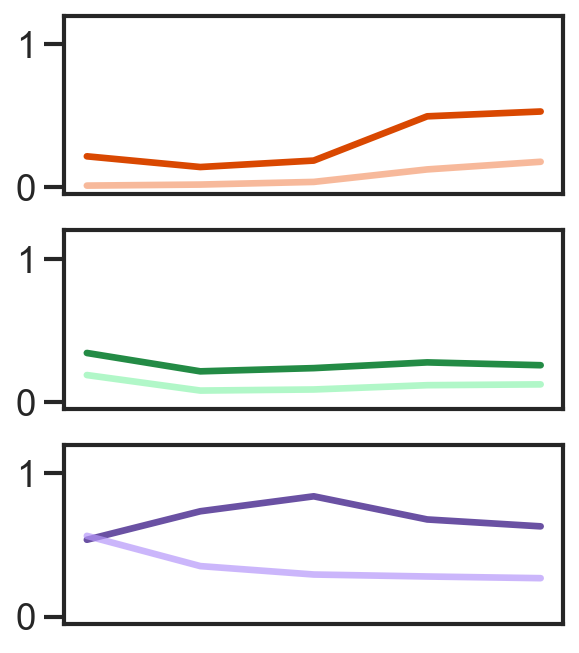

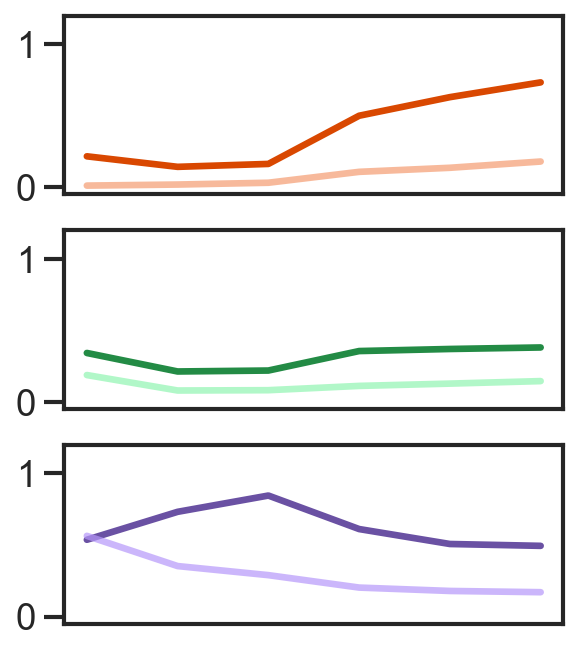

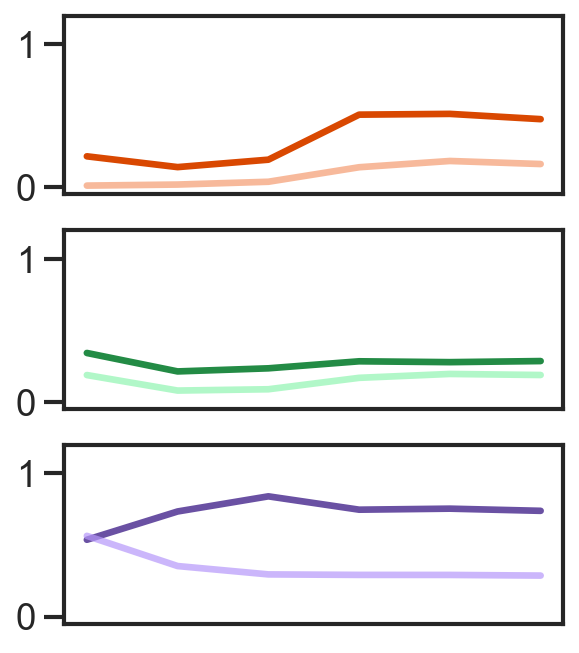

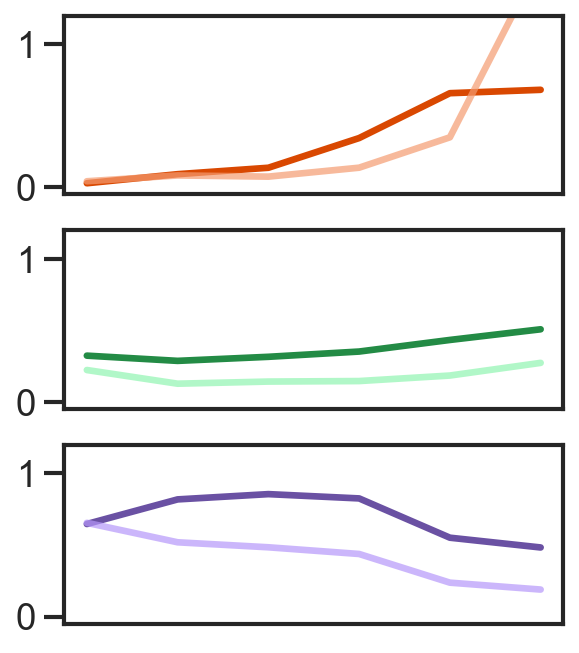

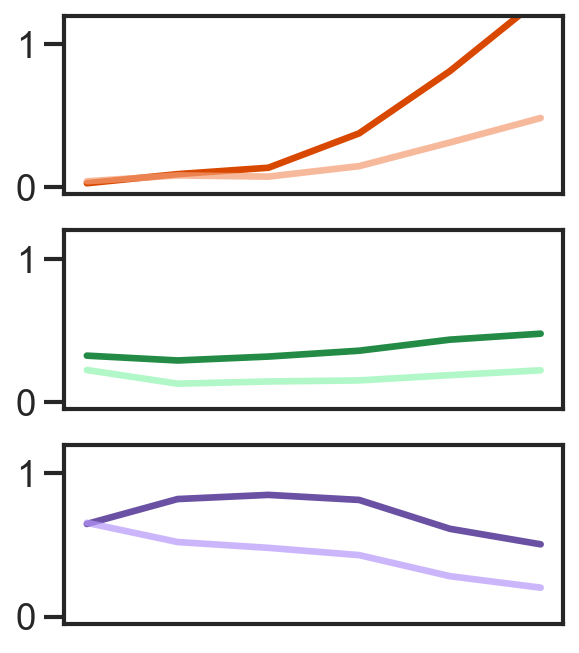

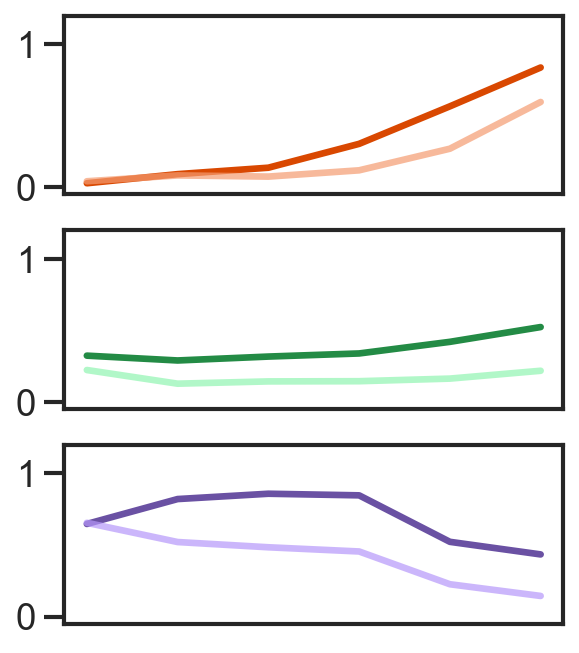

In [192]:
plot_source_target(to_plot1, 'endo1','end_source','end_target', xval = 'RT')

plot_source_target(to_plot2, 'mes1','mes_source','mes_target', xval = 'RT')
plot_source_target(to_plot2, 'mes2','mes_source','mes_target', xval = 'RT')
plot_source_target(to_plot2, 'mes3','mes_source','mes_target', xval = 'RT')

plot_source_target(to_plot3, 'ect1','ect_source','ect_target', xval = 'RT')
plot_source_target(to_plot3, 'ect2','ect_source','ect_target', xval = 'RT')
plot_source_target(to_plot3, 'ect3','ect_source','ect_target', xval = 'RT')